In [ ]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

!curl -O https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
words = open('names.txt', 'r').read().splitlines()


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  222k  100  222k    0     0  2362k      0 --:--:-- --:--:-- --:--:-- 2370k


In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)


In [ ]:
def build_dataset(words):
  block_size = 3
  X, Y = [], []
  for w in words:
     context = [0] * block_size
     for ch in w + '.':
       ix= stoi[ch]
       X.append(context)
       Y.append(ix)
       context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


In [33]:
g_small = torch.Generator().manual_seed(2147483647)
C_small  = torch.randn((vocab_size, 2), generator=g_small)
W1_small = torch.randn((2*block_size, 100), generator=g_small)*5/3/(2*block_size)**0.5
b1_small = torch.randn(100, generator=g_small)*0.01
W2_small = torch.randn((100, vocab_size), generator=g_small)*0.01
b2_small = torch.zeros(vocab_size)
parameters_small = [C_small, W1_small, b1_small, W2_small, b2_small]
for p in parameters_small:
    p.requires_grad_(True)

for i in range(5000):
    ix = torch.randint(0, Xtr.shape[0], (32,), generator=g_small)
    emb = C_small[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 2*block_size) @ W1_small + b1_small)
    logits = h @ W2_small + b2_small
    loss = F.cross_entropy(logits, Ytr[ix])
    for p in parameters_small:
        p.grad = None
    loss.backward()
    lr = 0.1
    for p in parameters_small:
        p.data += -lr * p.grad

with torch.no_grad():
    emb = C_small[Xdev]
    h = torch.tanh(emb.view(-1, 2*block_size) @ W1_small + b1_small)
    logits = h @ W2_small + b2_small
    print("küçük model (n_emb=2, n_hidden=100) dev loss:", F.cross_entropy(logits, Ydev).item())

küçük model (n_emb=2, n_hidden=100) dev loss: 2.4021050930023193


In [ ]:
n_emb = 10
n_hidden = 200
block_size = 3
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g)*5/3/(n_emb * block_size)**0.5
#b1 = torch.randn(n_hidden, generator=g)*0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g)*0.01
b2 = torch.randn(vocab_size, generator=g)*0
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))
parameters=[C, W1, b1, W2, b2, bngain, bnbias]

In [ ]:
for p in parameters:
    p.requires_grad_(True)

In [ ]:
#lre = torch.linspace(-3, 0, 1000)
#lrs = 10**lre
#lri = []
lossi = []
stepi = []
batch_size = 32
max_steps = 20000

In [ ]:
for i in range(max_steps):
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix]
  emb = C[Xb]
  embcat = emb.view(-1, n_emb * block_size)
  hpreact = embcat @ W1 + b1
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain*(hpreact - bnmeani) / bnstdi + bnbias

  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Yb)
  for p in parameters:
    p.grad =  None
  loss.backward()
  lr = 0.1 if i<10000 else 0.01
  for p in parameters:
   # lr = lrs[i]
    p.data += -lr * p.grad
 # lri.append(lre[i].item())
  lossi.append(loss.log10().item())
  stepi.append(i)
print(loss.item())

1.639176607131958


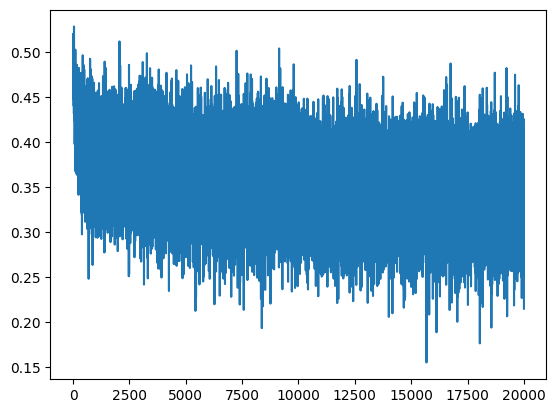

In [ ]:
plt.plot(stepi, lossi)

In [ ]:
g2 = torch.Generator().manual_seed(2147483647)
C2  = torch.randn((vocab_size, n_emb), generator=g2)
W1_2 = torch.randn((n_emb*block_size, n_hidden), generator=g2)*5/3/(n_emb*block_size)**0.5
b1_2 = torch.randn(n_hidden, generator=g2)*0.01
W2_2 = torch.randn((n_hidden, vocab_size), generator=g2)*0.01
b2_2 = torch.zeros(vocab_size)
parameters2 = [C2, W1_2, b1_2, W2_2, b2_2]
for p in parameters2:
    p.requires_grad_(True)

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g2)
    emb = C2[Xtr[ix]]
    h = torch.tanh(emb.view(-1, n_emb*block_size) @ W1_2 + b1_2)
    logits = h @ W2_2 + b2_2
    loss = F.cross_entropy(logits, Ytr[ix])
    for p in parameters2:
        p.grad = None
    loss.backward()
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters2:
        p.data += -lr * p.grad

with torch.no_grad():
    emb = C2[Xdev]
    h = torch.tanh(emb.view(-1, n_emb*block_size) @ W1_2 + b1_2)
    logits = h @ W2_2 + b2_2
    print("Batch Norm'suz dev loss:", F.cross_entropy(logits, Ydev).item())

Batch Norm'suz dev loss: 2.1726036071777344


In [ ]:
emb = C[Xtr[:32]]
hpreact = emb.view(-1, n_emb * block_size) @ W1 + b1
hpreact = bngain*(hpreact - bnmean_running) / bnstd_running + bnbias
h = torch.tanh(hpreact)
logits = h @ W2 + b2

# elle hesaplama
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
loss_manual = -probs[torch.arange(32), Ytr[:32]].log().mean()

# cross_entropy
loss_ce = F.cross_entropy(logits, Ytr[:32])

print("manual:", loss_manual.item())
print("cross_entropy:", loss_ce.item())

manual: 2.506410837173462
cross_entropy: 2.506410598754883


In [34]:
with torch.no_grad():
    emb = C[Xtr]
    hpreact = emb.view(-1, n_emb*block_size) @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    print("train:", F.cross_entropy(logits, Ytr).item())

    emb = C[Xdev]
    hpreact = emb.view(-1, n_emb*block_size) @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    print("dev:", F.cross_entropy(logits, Ydev).item())

train: 2.1880016326904297
dev: 2.196345090866089


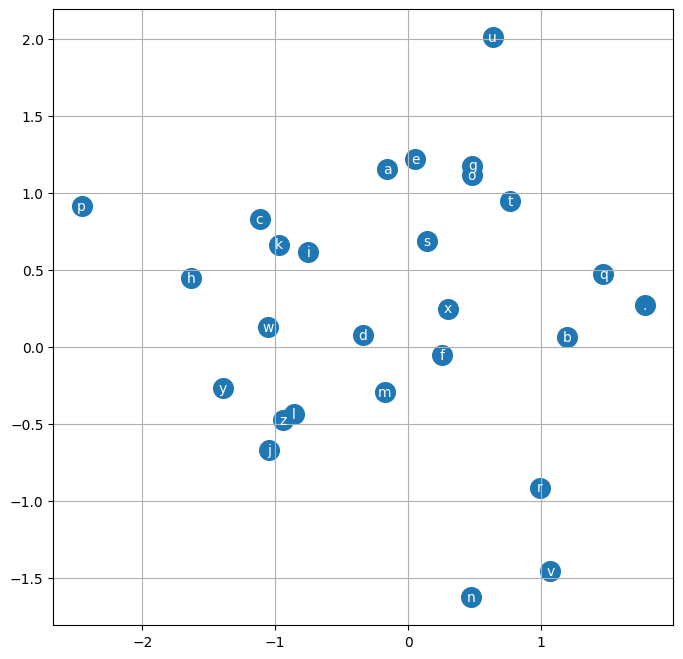

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
  plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')


In [ ]:
for _ in range(20):
  out = []
  context = [0] * block_size
  while True:
    emb = C[torch.tensor([context])]
    hpreact = emb.view(1, -1) @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break
  print(''.join(itos[i] for i in out))

emar.
dason.
nacey.
auhah.
priyan.
zeilyandivauce.
sunj.
natalie.
aliton.
joxiya.
vee.
dactje.
cens.
caele.
naine.
masta.
mecl.
lamariyah.
faraluniellee.
creen.


kötü init loss: 24.412067413330078


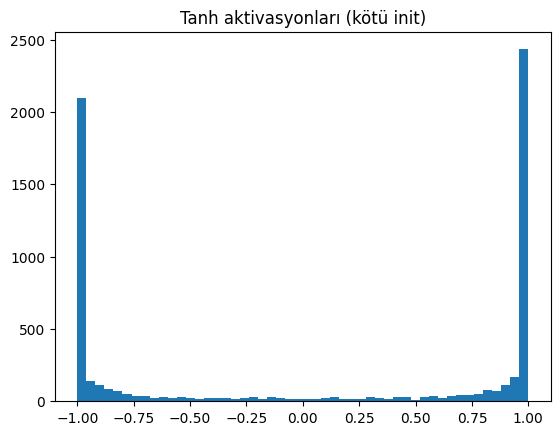

In [ ]:
g_bad = torch.Generator().manual_seed(2147483647)
C_bad  = torch.randn((vocab_size, n_emb), generator=g_bad)
W1_bad = torch.randn((n_emb * block_size, n_hidden), generator=g_bad)
b1_bad = torch.randn(n_hidden, generator=g_bad)
W2_bad = torch.randn((n_hidden, vocab_size), generator=g_bad)
b2_bad = torch.randn(vocab_size, generator=g_bad)

emb = C_bad[Xtr[:32]]
hpreact_bad = emb.view(-1, n_emb*block_size) @ W1_bad + b1_bad
h_bad = torch.tanh(hpreact_bad)
logits_bad = h_bad @ W2_bad + b2_bad
loss_bad = F.cross_entropy(logits_bad, Ytr[:32])
print("kötü init loss:", loss_bad.item())

plt.hist(h_bad.view(-1).tolist(), 50)
plt.title("Tanh aktivasyonları (kötü init)")
plt.show()

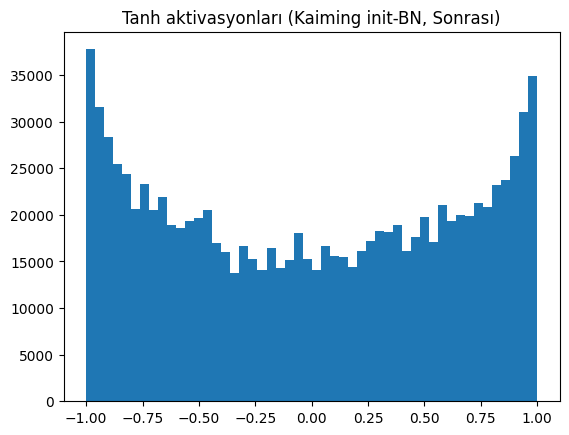

In [37]:
with torch.no_grad():
    emb = C[Xtr[:5000]]
    hpreact_good = emb.view(-1, n_emb*block_size) @ W1
    hpreact_good = bngain*(hpreact_good - bnmean_running)/bnstd_running + bnbias
    h_good = torch.tanh(hpreact_good)

plt.hist(h_good.view(-1).numpy(), 50)
plt.title("Tanh aktivasyonları (Kaiming init-BN, Sonrası)")
plt.show()

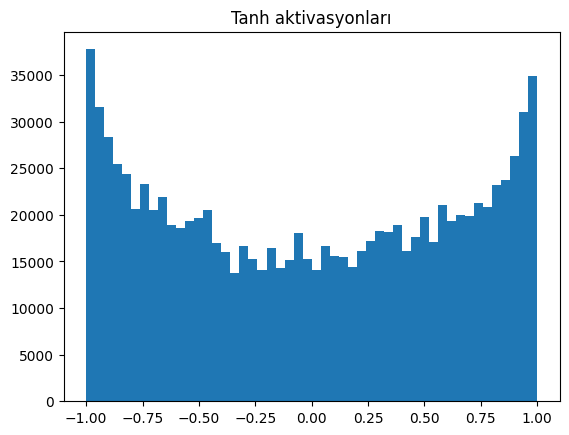

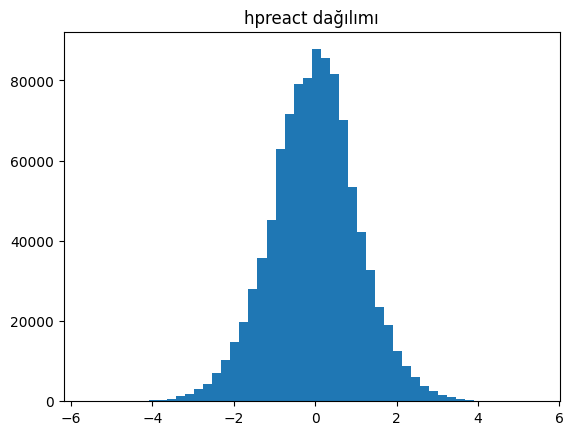

In [38]:
with torch.no_grad():
    emb = C[Xtr[:5000]]
    hpreact = emb.view(-1, n_emb * block_size) @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)

plt.hist(h.view(-1).numpy(), 50)
plt.title("Tanh aktivasyonları")
plt.show()

plt.hist(hpreact.view(-1).numpy(), 50)
plt.title("hpreact dağılımı")
plt.show()

In [ ]:
!curl -O https://raw.githubusercontent.com/tarikbahar/Turkish_names_and_surnames_dataset/master/Turkce_isimler_listesi.txt
tr_normalization_map=str.maketrans({
    'İ': 'i',
    'I': 'ı',
    'Â': 'a', 'â': 'a',
    'Î': 'i', 'î': 'i',
    'Û': 'u', 'û': 'u',
})

with open('Turkce_isimler_listesi.txt', 'r', encoding='utf-16') as f:
    lines=f.read().splitlines()

processed_words=[]

for line in lines:
    line=line.strip()
    if not line:
        continue
    raw_name=line.split(',')[0].strip()

    clean_name=raw_name.translate(tr_normalization_map).lower()

    if clean_name and clean_name.isalpha():
        processed_words.append(clean_name)

tr_words=sorted(list(set(processed_words)))


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 72050  100 72050    0     0   335k      0 --:--:-- --:--:-- --:--:--  335k


In [ ]:
tr_chars = sorted(list(set(''.join(tr_words))))
tr_stoi = {s:i+1 for i,s in enumerate(tr_chars)}
tr_stoi['.'] = 0
tr_itos = {i:s for s,i in tr_stoi.items()}
tr_vocab_size = len(tr_itos)
print(tr_vocab_size)
print(tr_chars)

30
['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'y', 'z', 'ç', 'ö', 'ü', 'ğ', 'ı', 'ş']


In [ ]:
N_tr = torch.zeros((tr_vocab_size, tr_vocab_size), dtype=torch.int32)
for w in tr_words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        N_tr[tr_stoi[ch1], tr_stoi[ch2]] += 1

P_tr = (N_tr + 1).float()
P_tr /= P_tr.sum(1, keepdim=True)

In [ ]:
bigram_tr_loss = 0
n_count = 0
for w in tr_words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1, ix2 = tr_stoi[ch1], tr_stoi[ch2]
        bigram_tr_loss -= torch.log(P_tr[ix1, ix2])
        n_count += 1
print("bigram Türkçe loss:", bigram_tr_loss.item() / n_count)

bigram Türkçe loss: 2.454579630082627


In [ ]:
def build_dataset_tr(tr_words):
  block_size = 3
  X, Y = [], []
  for w in tr_words:
     context = [0] * block_size
     for ch in w + '.':
       ix= tr_stoi[ch]
       X.append(context)
       Y.append(ix)
       context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

random.seed(42)
random.shuffle(tr_words)
n1_tr = int(0.8*len(tr_words))
n2_tr = int(0.9*len(tr_words))

Xtr_tr, Ytr_tr = build_dataset_tr(tr_words[:n1_tr])
Xdev_tr, Ydev_tr = build_dataset_tr(tr_words[n1_tr:n2_tr])
Xte_tr, Yte_tr = build_dataset_tr(tr_words[n2_tr:])

In [ ]:
g_tr = torch.Generator().manual_seed(2147483647)
C_tr  = torch.randn((tr_vocab_size, n_emb), generator=g_tr)
W1_tr = torch.randn((n_emb * block_size, n_hidden), generator=g_tr) * 5/3 / (n_emb*block_size)**0.5
W2_tr = torch.randn((n_hidden, tr_vocab_size), generator=g_tr) * 0.01
b2_tr = torch.zeros(tr_vocab_size)

bngain_tr = torch.ones((1, n_hidden))
bnbias_tr = torch.zeros((1, n_hidden))
bnmean_running_tr = torch.zeros((1, n_hidden))
bnstd_running_tr = torch.ones((1, n_hidden))

parameters_tr = [C_tr, W1_tr, W2_tr, b2_tr, bngain_tr, bnbias_tr]
for p in parameters_tr:
    p.requires_grad_(True)

In [ ]:
for i in range(max_steps):
    ix = torch.randint(0, Xtr_tr.shape[0], (batch_size,), generator=g_tr)
    emb = C_tr[Xtr_tr[ix]]
    hpreact = emb.view(-1, n_emb*block_size) @ W1_tr
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain_tr * (hpreact - bnmeani) / bnstdi + bnbias_tr

    with torch.no_grad():
        bnmean_running_tr = 0.999*bnmean_running_tr + 0.001*bnmeani
        bnstd_running_tr = 0.999*bnstd_running_tr + 0.001*bnstdi

    h = torch.tanh(hpreact)
    logits = h @ W2_tr + b2_tr
    loss = F.cross_entropy(logits, Ytr_tr[ix])

    for p in parameters_tr:
        p.grad = None
    loss.backward()
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters_tr:
        p.data += -lr * p.grad

print(loss.item())

2.034271240234375


In [ ]:
with torch.no_grad():
    emb = C_tr[Xtr_tr]
    hpreact = emb.view(-1, n_emb*block_size) @ W1_tr
    hpreact = bngain_tr * (hpreact - bnmean_running_tr) / bnstd_running_tr + bnbias_tr
    h = torch.tanh(hpreact)
    logits = h @ W2_tr + b2_tr
    print("train:", F.cross_entropy(logits, Ytr_tr).item())

    emb = C_tr[Xdev_tr]
    hpreact = emb.view(-1, n_emb*block_size) @ W1_tr
    hpreact = bngain_tr * (hpreact - bnmean_running_tr) / bnstd_running_tr + bnbias_tr
    h = torch.tanh(hpreact)
    logits = h @ W2_tr + b2_tr
    print("dev:", F.cross_entropy(logits, Ydev_tr).item())

train: 1.8926891088485718
dev: 2.144973039627075


In [ ]:
g_sample_tr = torch.Generator().manual_seed(2147483647)
print(f"{'Bigram':<20} | {'MLP ve BN':<20}")
for _ in range(10):
    out_bg = []
    ix = 0
    while True:
        p = P_tr[ix]
        ix = torch.multinomial(p, num_samples=1, generator=g_sample_tr).item()
        if ix == 0:
            break
        out_bg.append(tr_itos[ix])
    bg_name = ''.join(out_bg)

    out_mlp = []
    context = [0]*block_size
    while True:
        emb = C_tr[torch.tensor([context])]
        hpreact = emb.view(1,-1) @ W1_tr
        hpreact = bngain_tr*(hpreact-bnmean_running_tr)/bnstd_running_tr + bnbias_tr
        h = torch.tanh(hpreact)
        logits = h @ W2_tr + b2_tr
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g_sample_tr).item()
        context = context[1:] + [ix]
        if ix == 0:
            break
        out_mlp.append(tr_itos[ix])
    mlp_name = ''.join(out_mlp)

    print(f"{bg_name:<20} | {mlp_name:<20}")

Bigram               | MLP ve BN           
unsrançmokslbör      | ezgeren             
stmur                | bayulçuz            
batin                | alpurışbeğ          
a                    | hin                 
bürsayeç             | ezgüyüker           
eyekadumı            | kelay               
ekar                 | japa                
aydum                | ulus                
akç                  | ifgendar            
babayunakı           | erimen              
